In [9]:
from datasets import load_dataset
import torch
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from PIL import Image
import os
import base64
from io import BytesIO
from IPython.display import display, Markdown, HTML
import glob
from pdf2image import convert_from_path
import linecache
# Import olmocr utilities
from olmocr.prompts.prompts import build_no_anchoring_v4_yaml_prompt
from olmocr.data.renderpdf import render_pdf_to_base64png
import re

In [2]:
# Load Model and Processor
MODEL_PATH = "/home/dsi/yefimnu/projects/olmocr/olmocr-finetuned-model"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading model from {MODEL_PATH} on {device}...")
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_PATH, 
    torch_dtype=torch.bfloat16, 
    device_map=device
)
processor = AutoProcessor.from_pretrained(MODEL_PATH)
print("Model loaded successfully!")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading model from /home/dsi/yefimnu/projects/olmocr/olmocr-finetuned-model on cuda...


Loading checkpoint shards: 100%|██████████| 4/4 [00:03<00:00,  1.21it/s]
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.
The tokenizer you are loading from '/home/dsi/yefimnu/projects/olmocr/olmocr-finetuned-model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Model loaded successfully!


In [14]:
def run_inference(image_input, prompt_text=None):
    if prompt_text is None:
        prompt_text = build_no_anchoring_v4_yaml_prompt()
        
    # Prepare inputs
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_input},
                {"type": "text", "text": prompt_text},
            ],
        }
    ]
    
    text_input = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    inputs = processor(
        text=[text_input], 
        images=[image_input], 
        padding=True, 
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Generate
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=2048)
    
    # Decode
    input_ids = inputs.get("input_ids")
    if input_ids is None:
        # Fallback if input_ids is not present (though it should be for this model)
        # In some versions of transformers/models, key might differ or return format varies
        raise ValueError("Could not retrieve input_ids from processor output")

    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]
    extracted_latex = output_text.split('---')[-1].strip()
    return extracted_latex

def compare_results(pdf_filename, generated_text, ground_truth_dir="olmocr/data/aida-data/train"):
    # Display paths
    gt_path = os.path.join(ground_truth_dir, f"{pdf_filename}.md")
    pdf_path = os.path.join(ground_truth_dir, f"{pdf_filename}.pdf")
    
    # Render Original PDF Page 1
    try:
        images = convert_from_path(pdf_path, first_page=1, last_page=1)
        if images:
            print(f"--- Original PDF: {pdf_filename}.pdf ---")
            display(images[0])
    except Exception as e:
        print(f"Error rendering PDF: {e}")

    # Display Generated Markdown
    print("\n--- Generated Markdown ---")
    display(Markdown(generated_text))

    # Display Ground Truth
    print("\n--- Ground Truth ---")
    if os.path.exists(gt_path):
        with open(gt_path, 'r') as f:
            gt_content = f.read()
            # Extract LaTeX from ground truth markdown
            latex_matches = gt_content.split('---')[-1].strip()
        display(Markdown(latex_matches))
    else:
        print("Ground truth file not found.")

Processing 009000...
--- Original PDF: 009000.pdf ---


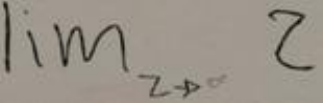


--- Generated Markdown ---


\[
\lim_{z\to\infty}z
\]


--- Ground Truth ---


\[ \lim_{z\to\infty}2 \]

In [15]:
# Pick a file to test
filename = "009000" # Change this to any ID you want to test
pdf_dir = "olmocr/data/aida-data/train"
pdf_path = os.path.join(pdf_dir, f"{filename}.pdf")

print(f"Processing {filename}...")

# Render the PDF page to an image for the model
try:
    images = convert_from_path(pdf_path, first_page=1, last_page=1)
    input_image = images[0]
    
    # Run Inference
    output = run_inference(input_image)
    
    # Compare
    compare_results(filename, output, ground_truth_dir=pdf_dir)
    
except Exception as e:
    print(f"Error processing {filename}: {e}")

Processing 056861...
--- Original PDF: 056861.pdf ---


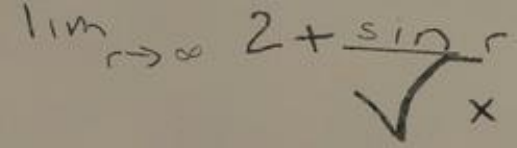


--- Generated Markdown ---


\[ \lim_{r\to\infty}2+\frac{\sin{r}}{\sqrt{x}} \]


--- Ground Truth ---


\[ \lim_{r\to\infty}2+\frac{\sin{r}}{\sqrt{x}} \]

Processing 010987...
--- Original PDF: 010987.pdf ---


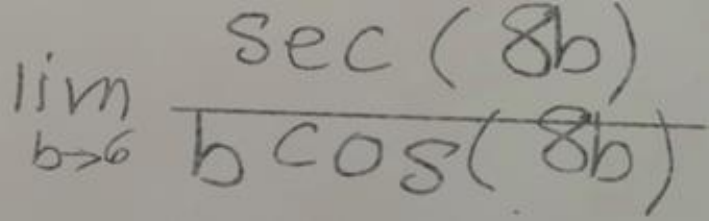


--- Generated Markdown ---


\[ \lim_{b\to6}\frac{\sec{\left(8b\right)}}{b\cos{\left(8b\right)}} \]


--- Ground Truth ---


\[ \lim_{b\to6}\frac{\sec{\left(8b\right)}}{b\cos{\left(8b\right)}} \]

Processing 072249...
--- Original PDF: 072249.pdf ---


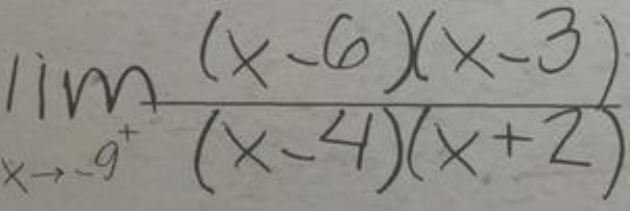


--- Generated Markdown ---


\[ \lim_{x\to-9^{+}}\frac{\left(x-6\right)\left(x-3\right)}{\left(x-4\right)\left(x+2\right)} \]


--- Ground Truth ---


\[ \lim_{x\to-9^{+}}\frac{\left(x-6\right)\left(x-3\right)}{\left(x-4\right)\left(x+2\right)} \]

Processing 012001...
--- Original PDF: 012001.pdf ---


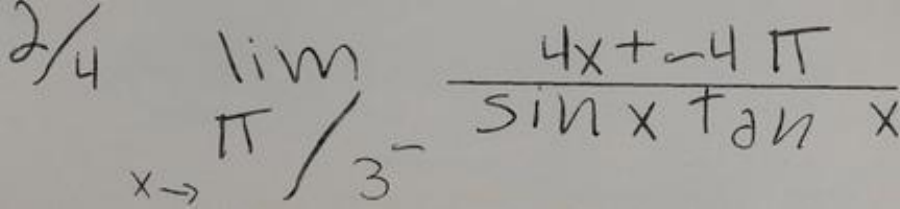


--- Generated Markdown ---


\[ \frac{2}{4}\lim_{x\to\pi/3^{-}}\frac{4x+-4\pi}{\sin{x}+\tan{x}} \]


--- Ground Truth ---


\[ 2/4\lim_{x\to\pi/3^{-}}\frac{4x+-4\pi}{\sin{x}\tan{x}} \]

Processing 002780...
--- Original PDF: 002780.pdf ---


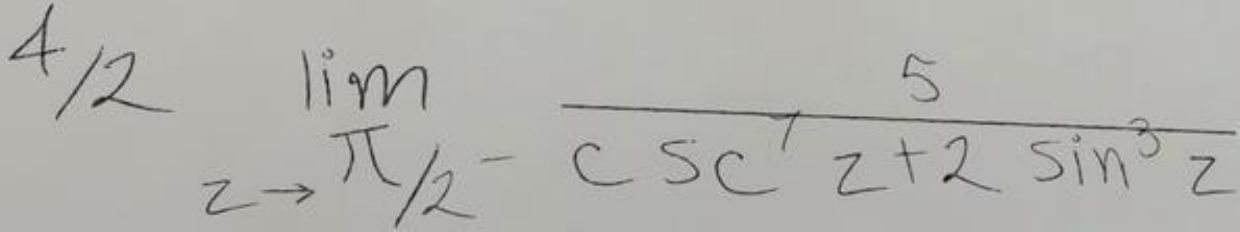


--- Generated Markdown ---


\[ \lim_{z\to\pi/2^{-}}\frac{5}{\csc^{7}{z}+2\sin^{3}{z}}^{4/2} \]


--- Ground Truth ---


\[ 4/2\lim_{z\to\pi/2^{-}}\frac{5}{\csc^{7}{z}+2\sin^{3}{z}} \]

In [16]:
# Optional: Run on a batch of 5 random files
import random

# Get all PDF files in the directory
all_pdfs = glob.glob(os.path.join(pdf_dir, "*.pdf"))
sample_pdfs = random.sample(all_pdfs, 5)

for pdf_file in sample_pdfs:
    filename = os.path.basename(pdf_file).replace(".pdf", "")
    print(f"Processing {filename}...")
    
    try:
        images = convert_from_path(pdf_file, first_page=1, last_page=1)
        input_image = images[0]
        output = run_inference(input_image)
        compare_results(filename, output, ground_truth_dir=pdf_dir)
    except Exception as e:
        print(f"Error: {e}")

Found 1 file(s) to process

File: test.pdf

--- Page 1/1 ---


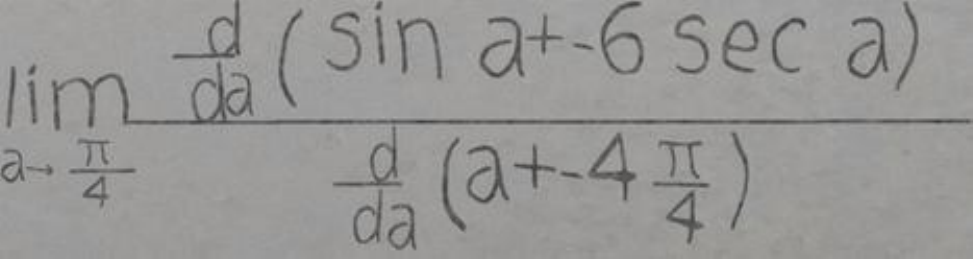

Generated Markdown:


\[
\lim_{a\to\frac{\pi}{4}}\frac{\frac{d}{da}\left(\sin{a}+-6\sec{a}\right)}{\frac{d}{da}\left(a+-4\frac{\pi}{4}\right)}
\]

--------------------------------------------------------------------------------


In [17]:
# --- Run inference on local images/PDFs (no ground truth) ---
LOCAL_PATH = "pdfs_imgs"  # single file or directory

supported_img_exts = (".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".webp")
supported_pdf_ext = ".pdf"

# Collect files
if os.path.isfile(LOCAL_PATH):
    local_files = [LOCAL_PATH]
elif os.path.isdir(LOCAL_PATH):
    local_files = sorted([
        os.path.join(LOCAL_PATH, f) for f in os.listdir(LOCAL_PATH)
        if f.lower().endswith(supported_img_exts + (supported_pdf_ext,))
    ])
else:
    raise FileNotFoundError(f"Path not found: {LOCAL_PATH}")

print(f"Found {len(local_files)} file(s) to process\n")

for fpath in local_files:
    fname = os.path.basename(fpath)
    print(f"{'='*80}")
    print(f"File: {fname}")

    try:
        if fpath.lower().endswith(supported_pdf_ext):
            pages = convert_from_path(fpath)
            for page_num, page_img in enumerate(pages, start=1):
                print(f"\n--- Page {page_num}/{len(pages)} ---")
                display(page_img)
                output = run_inference(page_img)
                print("Generated Markdown:")
                display(Markdown(output))
        else:
            img = Image.open(fpath).convert("RGB")
            display(img)
            output = run_inference(img)
            print("\n--- Generated Markdown ---")
            display(Markdown(output))
    except Exception as e:
        print(f"Error processing {fname}: {e}")

    print("-" * 80)